In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from experiments.plotting import _plot_SRE_distribution, view_correlation
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
    simulate_circuit,
)
from src.utils import configure_logger


In [6]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

# Circuits et graphes pour chaque famille

In [22]:
family = "quansistor"
n_qubits = 15
n_layers = 30
backend = "pennylane"
seed = 1

img, qc, graph_data, gate_count = simulate_circuit(
    family=family,
    n_qubits=n_qubits,
    n_layers=n_layers,
    backend=backend,
    seed=seed,
)


2026-06-10 19:34:04,236 - scripts.simulate_circuits - INFO - Simulating circuit family: quansistor


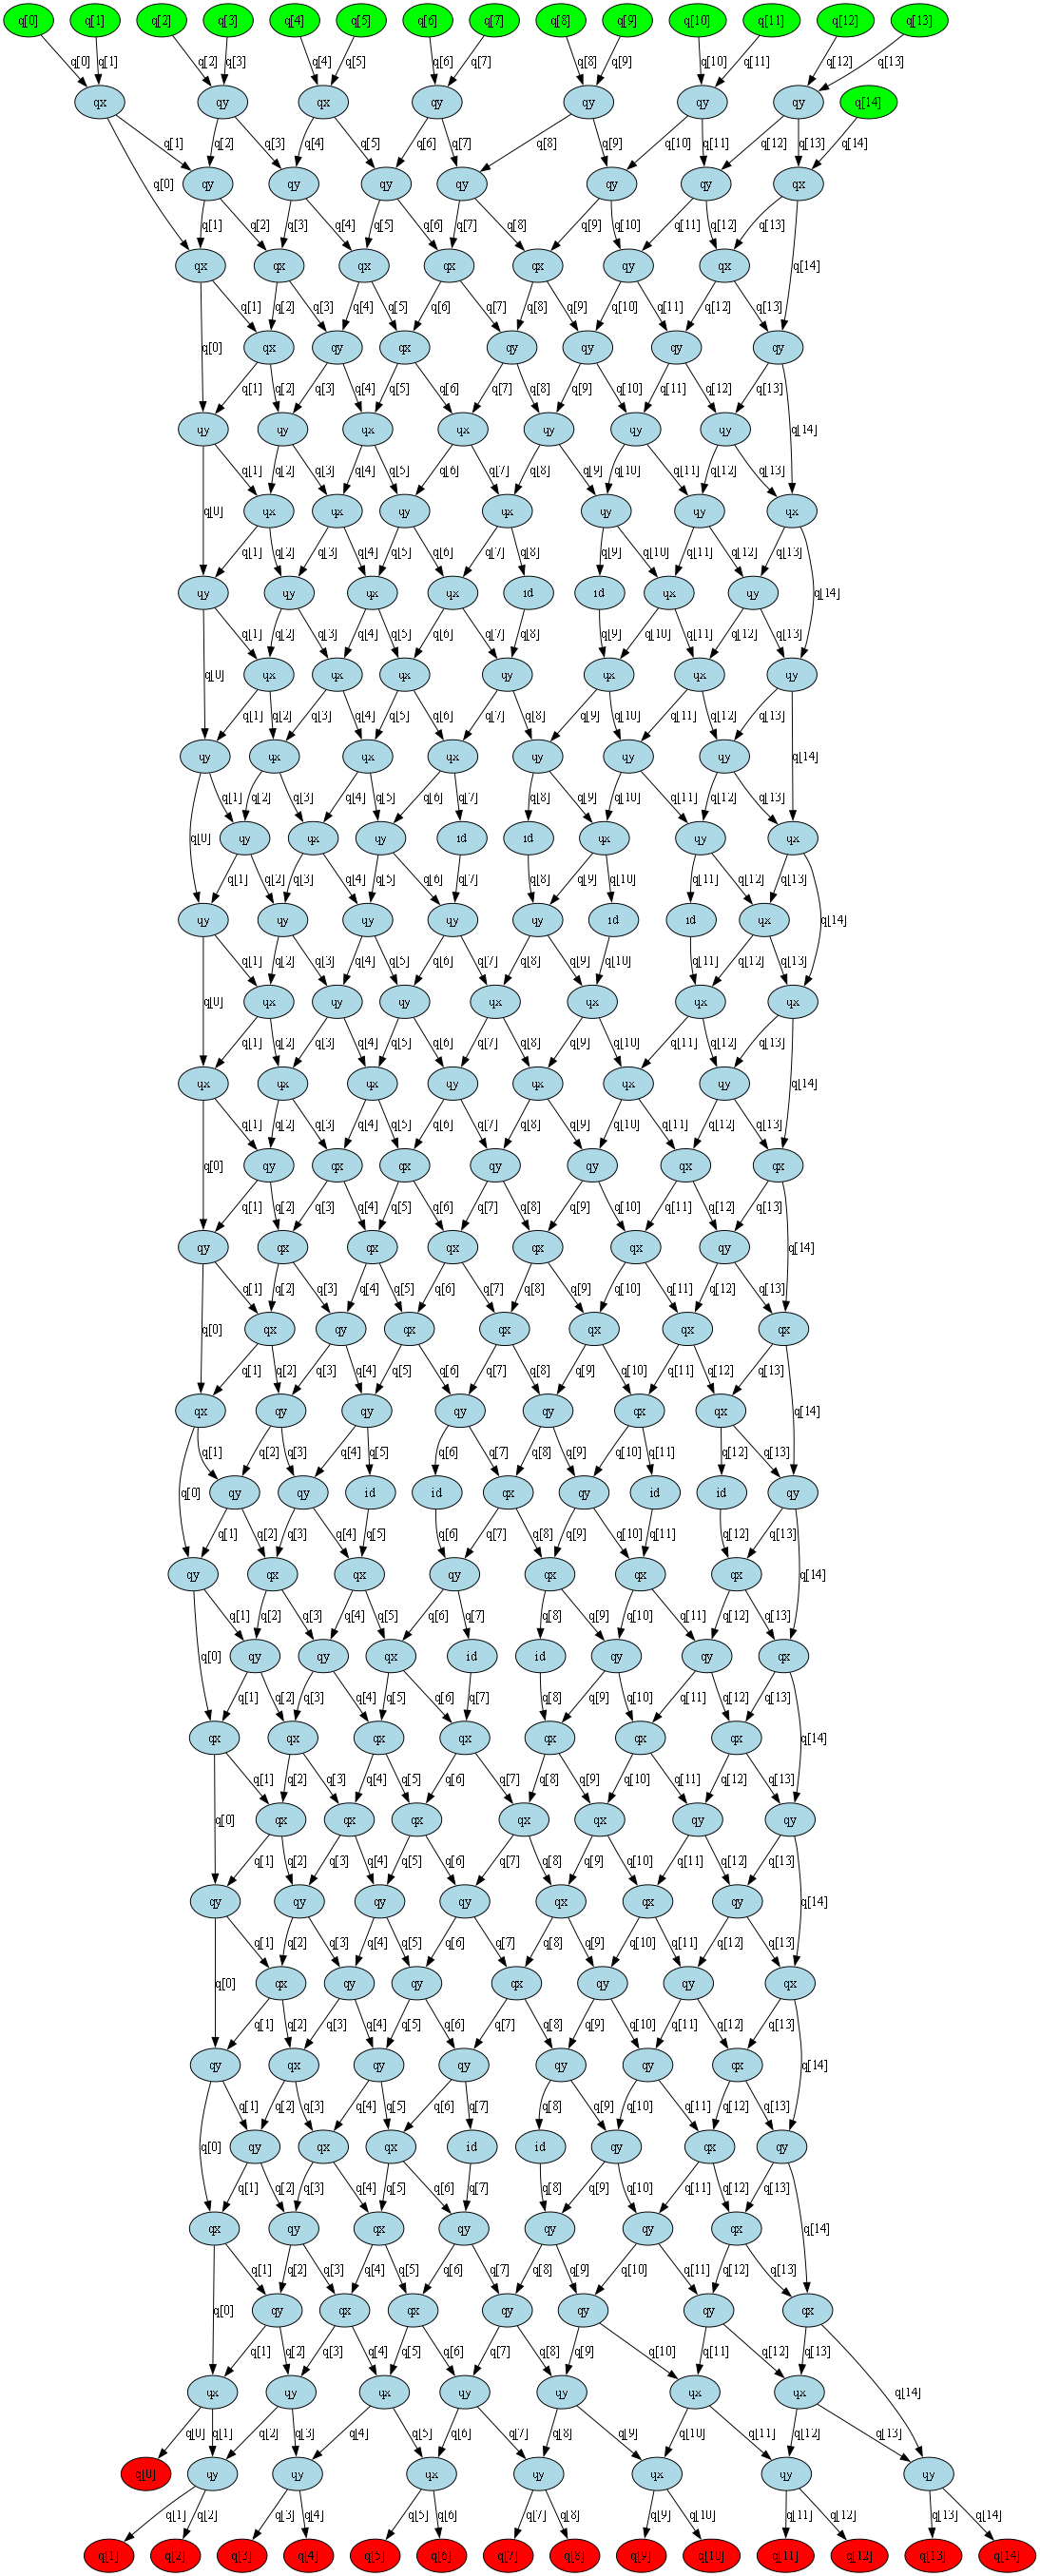

In [23]:
from IPython.display import display, Image as IPyImage
from io import BytesIO

try:
    # Normalize for notebook display
    from PIL import Image as PILImage  # type: ignore
    if isinstance(img, PILImage.Image) and img.mode == 'RGBA':
        img = img.convert('RGB')
    display(img)
except Exception:
    # Fallback to PNG bytes
    try:
        bio = BytesIO()
        img.save(bio, format='PNG')
        display(IPyImage(data=bio.getvalue(), format='png'))
    except Exception:
        fig = qc.draw(output="mpl")
        display(fig)

# Résultats pour le calcul théorique brute sur 1 seul régime (identity-like et saturé)

### Calcul du SRE pour n=12 qubits